In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bidr_relight.plot import plot_ax, calculate_shared_limits
from bidr_relight.bidr_process import project_to_log_chromaticity_plane

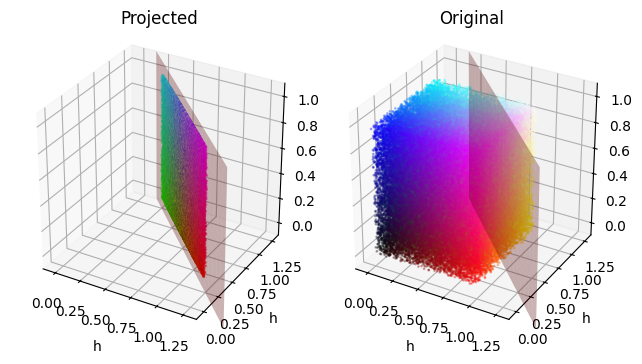

In [ ]:
syn_isd_map = np.zeros((300, 300, 3))
syn_isd_map[..., 0] = 1.0 / 1.4142135623730951
syn_isd_map[..., 1] = 1.0 / 1.4142135623730951
syn_img = np.random.rand(300, 300, 3)
projected = project_to_log_chromaticity_plane(
    syn_img, isd_map=syn_isd_map, plane_offset=np.array((0.5, 1, 1))
)

# Create subplots
ax = plt.subplot(1, 2, 1, projection="3d")
ax2 = plt.subplot(1, 2, 2, projection="3d")

# Calculate shared limits
x_limits, y_limits, z_limits = calculate_shared_limits(
    [projected.reshape(-1, 3), syn_img.reshape(-1, 3)], padding=0.1
)
bounds = (x_limits, y_limits, z_limits)

for ax_curr in [ax, ax2]:
    ax_curr.set_box_aspect([1, 1, 1])
    ax_curr.set_xlim(x_limits)
    ax_curr.set_ylim(y_limits)
    ax_curr.set_zlim(z_limits)

# Plot both (plot_ax will set the limits)
plot_ax(
    projected.reshape(-1, 3),
    syn_img.reshape(-1, 3),
    ax,
    title="Projected",
    axis_labels=["h", "h", "h"],
    plane_normal=(1, 1, 0),
    plane_point=(0.5, 1, 1),
    bounds=bounds,
)

plot_ax(
    syn_img.reshape(-1, 3),
    syn_img.reshape(-1, 3),
    ax2,
    title="Original",
    axis_labels=["h", "h", "h"],
    plane_normal=(1, 1, 0),
    plane_point=(0.5, 1, 1),
    bounds=bounds,
)

# Copy viewing angle from ax to ax2 AFTER plotting
ax2.view_init(elev=ax.elev, azim=ax.azim, roll=ax.roll)

plt.tight_layout()
plt.show()